# 💎 Diamond Market Price Analysis
## Data Analytics & Visualization — Final Project
---
**Dataset:** Diamonds Dataset (Kaggle) | 53,940 records  
**Team:** Mustafa nabil  
**Course:** CET242 – Data Analytics and Visualization | Spring 2026  
**Instructors:** Dr. Nehal Anees | Eng. Aya Abdel Naby


---
## Step 1 — Domain & Problem Definition

### Domain: Retail / Gemstone Industry

### Problem Statement
> **Diamond pricing lacks transparency in the retail market. Buyers and small retailers cannot accurately determine whether a diamond is fairly priced based on its physical characteristics, leading to significant overpayment or missed value opportunities.**

### Problem Criteria
| Criterion | Status | Evidence |
|-----------|--------|----------|
| **Specific** | ✅ | Diamond retail pricing transparency |
| **Measurable** | ✅ | Price variation quantifiable ($326 – $18,823) |
| **Important** | ✅ | Affects millions of buyers and retailers worldwide |

### Key Business Questions
1. What physical features most strongly determine a diamond's price?
2. Does better quality (cut/color/clarity) always mean higher price?
3. Can we identify diamonds that are over- or under-priced?
4. What price ranges define natural market segments?

---
## Step 2 — Dataset Selection

### Dataset: Diamonds Dataset
- **Source:** Kaggle / R ggplot2 package (public domain)
- **Size:** 53,940 records × 10 features
- **Direct relevance:** All features are physical diamond characteristics or price

### Features Overview
| Feature | Type | Description |
|---------|------|-------------|
| `carat` | Numerical | Diamond weight (0.2 – 5.01) |
| `cut` | Categorical | Cut quality: Fair → Good → Very Good → Premium → Ideal |
| `color` | Categorical | Color grade: D (best) → J (worst) |
| `clarity` | Categorical | Clarity: IF (best) → I1 (worst) |
| `depth` | Numerical | Total depth percentage |
| `table` | Numerical | Width of diamond top (% of diameter) |
| `price` | Numerical | Price in USD ← **Target Variable** |
| `x` | Numerical | Length in mm |
| `y` | Numerical | Width in mm |
| `z` | Numerical | Depth in mm |

---
## Step 3 — Understanding and Preparing the Data

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [3]:
# ============================================================
# LOAD DATA
# ============================================================

import os

DATA_PATH = '../data/diamonds.csv'

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n--- Column Types ---")
print(df.dtypes)
print(f"\n--- First 5 Rows ---")
df.head()

 Dataset loaded: 53,940 rows × 10 columns

--- Column Types ---
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

--- First 5 Rows ---


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# ============================================================
# MISSING VALUES & DUPLICATES
# ============================================================

print("--- Missing Values ---")
print(df.isnull().sum())

print(f"\n--- Duplicates ---")
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups} ({dups/len(df)*100:.2f}%)")

--- Missing Values ---
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

--- Duplicates ---
Duplicate rows: 146 (0.27%)


In [5]:
# ============================================================
# DATA CLEANING
# ============================================================

print(f"Before cleaning: {len(df):,} rows")

# 1. Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates: {len(df):,} rows")

# 2. Remove impossible dimensions (x=0, y=0, z=0)
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(f"After removing zero dimensions: {len(df):,} rows")

# 3. Remove extreme outliers
df = df[(df['y'] < 20) & (df['z'] < 20)].copy()
print(f"After removing extreme outliers: {len(df):,} rows")

print("\n Data is clean and ready!")

Before cleaning: 53,940 rows
After removing duplicates: 53,794 rows
After removing zero dimensions: 53,775 rows
After removing extreme outliers: 53,772 rows

 Data is clean and ready!


### Data Cleaning Summary
| Issue | Count | Action |
|-------|-------|--------|
| Duplicate rows | 146 | Removed |
| Zero dimensions (x/y/z = 0) | 19 | Removed |
| Extreme outliers (y/z > 20mm) | 3 | Removed |
| **Final clean dataset** | **53,772** | **Ready ✅** |

In [6]:
# ============================================================
# STATISTICAL SUMMARY
# ============================================================

print("--- Numerical Features Summary ---")
df.describe().round(2)

--- Numerical Features Summary ---


,carat,depth,table,price,x,y,z
count,53772.00,53772.00,53772.00,53772.00,53772.00,53772.00,53772.00
mean,0.80,61.75,57.46,3931.14,5.73,5.73,3.54
std,0.47,1.43,2.23,3985.85,1.12,1.11,0.69
min,0.20,43.00,43.00,326.00,3.73,3.68,1.07
25%,0.40,61.00,56.00,951.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.00,6.54,6.54,4.03
max,5.01,79.00,95.00,18823.00,10.74,10.54,6.98


### Statistical Summary Observations
- **Price** ranges from $326 to $18,823 — very wide range (high variability)
- **Carat** mean is 0.80 — most diamonds are under 1 carat
- **Depth** is consistent (mean 61.75%) — well-controlled manufacturing
- **Price std ($3,985)** is larger than the mean ($3,931) — price is heavily skewed

---
## Step 4 — Defining KPIs (Key Performance Indicators)

| # | KPI | Definition | Why It Matters |
|---|-----|------------|----------------|
| 1 | **Average Price per Carat** | Total price / carat weight | Main pricing benchmark |
| 2 | **Price Range by Cut Quality** | Min/Max/Mean price per cut grade | Measures cut premium |
| 3 | **Price Range by Clarity** | Min/Max/Mean price per clarity grade | Measures clarity premium |
| 4 | **Price Range by Color** | Min/Max/Mean price per color grade | Measures color premium |
| 5 | **Anomaly Rate** | % of diamonds with unusual pricing | Identifies mispriced diamonds |

In [7]:
# ============================================================
# KPI CALCULATIONS
# ============================================================

print("=" * 50)
print("KPI 1 — Average Price per Carat")
print("=" * 50)
print(f"${df['price'].sum() / df['carat'].sum():,.2f} per carat")

print("\n" + "=" * 50)
print("KPI 2 — Price Range by Cut Quality")
print("=" * 50)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
print(df.groupby('cut')['price'].agg(['mean','min','max']).loc[cut_order].round(2))

print("\n" + "=" * 50)
print("KPI 3 — Price Range by Clarity")
print("=" * 50)
clarity_order = ['IF','VVS1','VVS2','VS1','VS2','SI1','SI2','I1']
print(df.groupby('clarity')['price'].agg(['mean','min','max']).loc[clarity_order].round(2))

print("\n" + "=" * 50)
print("KPI 4 — Price Range by Color")
print("=" * 50)
color_order = ['D','E','F','G','H','I','J']
print(df.groupby('color')['price'].agg(['mean','min','max']).loc[color_order].round(2))

print("\n" + "=" * 50)
print("KPI 5 — Anomaly Rate (price outliers per cut)")
print("=" * 50)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
anomalies = df[(df['price'] < Q1 - 1.5*IQR) | (df['price'] > Q3 + 1.5*IQR)]
print(f"Anomalous diamonds: {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}%)")

KPI 1 — Average Price per Carat
$4,929.17 per carat

KPI 2 — Price Range by Cut Quality
              mean  min    max
cut                           
Fair       4340.68  337  18574
Good       3916.28  327  18707
Very Good  3981.09  336  18818
Premium    4578.36  326  18823
Ideal      3462.21  326  18806

KPI 3 — Price Range by Clarity
            mean  min    max
clarity                     
IF       2870.57  369  18806
VVS1     2522.99  336  18777
VVS2     3286.53  336  18768
VS1      3841.75  327  18795
VS2      3925.61  334  18823
SI1      3994.27  326  18818
SI2      5053.75  326  18804
I1       3927.30  345  18531

KPI 4 — Price Range by Color
          mean  min    max
color                     
D      3172.59  357  18693
E      3079.82  326  18731
F      3726.78  342  18791
G      3999.09  354  18818
H      4476.17  337  18803
I      5079.84  334  18823
J      5326.42  335  18710

KPI 5 — Anomaly Rate (price outliers per cut)
Anomalous diamonds: 3,519 (6.54%)


---
## Step 5 — Hypothesis-Driven Analysis

| # | Hypothesis | Expected Outcome |
|---|------------|-----------------|
| H1 | **Carat is the strongest predictor of price** | Higher carat = higher price |
| H2 | **Better cut quality leads to higher price** | Ideal cut > Fair cut in price |
| H3 | **Better color grade leads to higher price** | D color > J color in price |
| H4 | **Better clarity leads to higher price** | IF clarity > I1 clarity in price |

> Each hypothesis will be tested in Step 6 — EDA and either **Accepted ✅** or **Rejected ❌** based on data evidence.

---
## Step 6 — Exploratory Data Analysis (EDA)

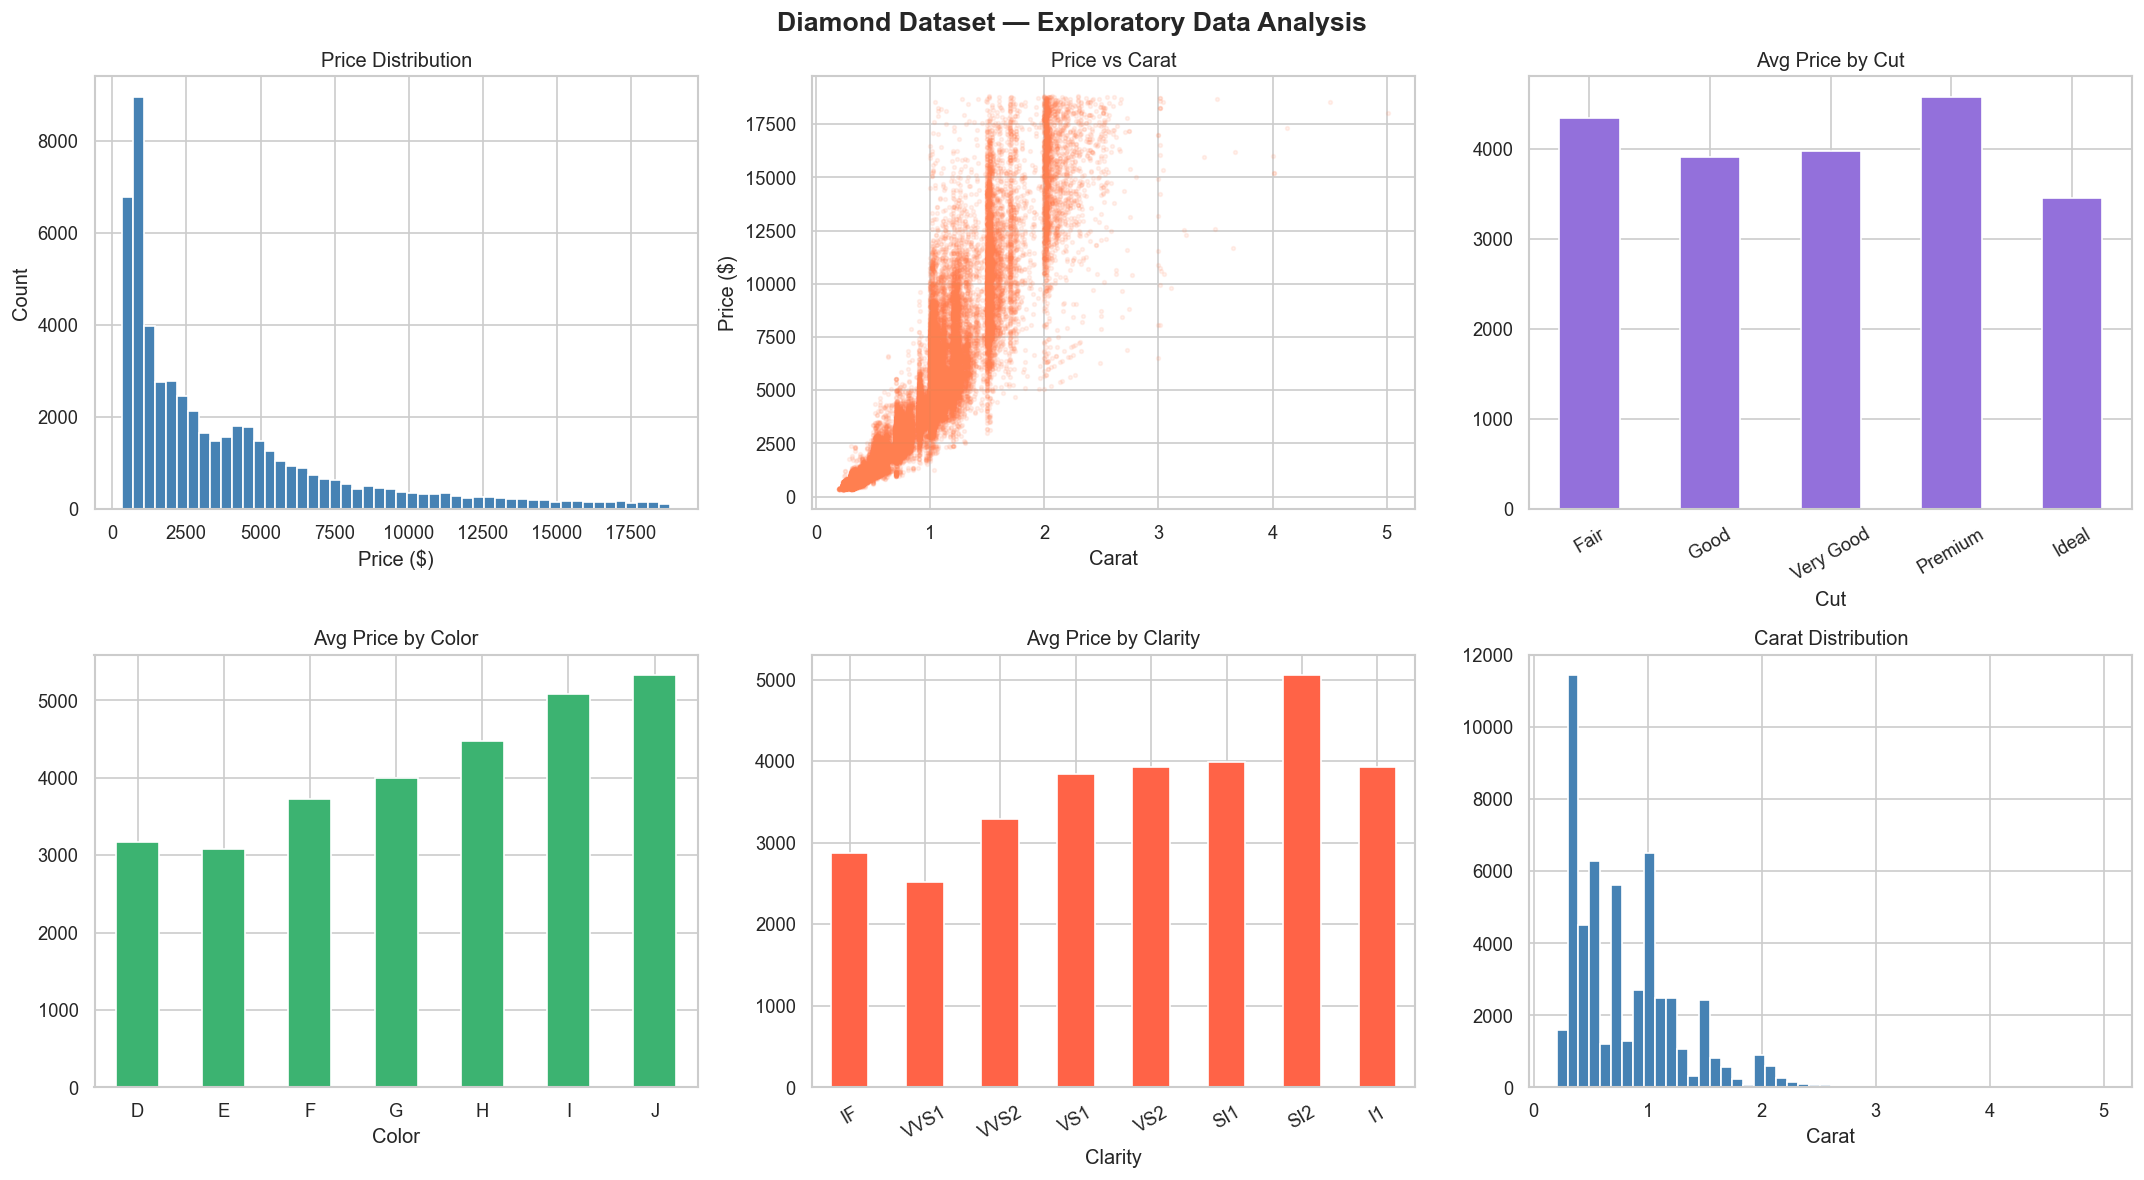

In [8]:
# ============================================================
# EDA — ALL VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Diamond Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

# 1. Price Distribution
axes[0,0].hist(df['price'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].set_ylabel('Count')

# 2. Price vs Carat
axes[0,1].scatter(df['carat'], df['price'], alpha=0.1, s=5, color='coral')
axes[0,1].set_title('Price vs Carat')
axes[0,1].set_xlabel('Carat')
axes[0,1].set_ylabel('Price ($)')

# 3. Avg Price by Cut
df.groupby('cut')['price'].mean().loc[cut_order].plot(
    kind='bar', ax=axes[0,2], color='mediumpurple', edgecolor='white')
axes[0,2].set_title('Avg Price by Cut')
axes[0,2].set_xlabel('Cut')
axes[0,2].tick_params(axis='x', rotation=30)

# 4. Avg Price by Color
df.groupby('color')['price'].mean().loc[color_order].plot(
    kind='bar', ax=axes[1,0], color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Avg Price by Color')
axes[1,0].set_xlabel('Color')
axes[1,0].tick_params(axis='x', rotation=0)

# 5. Avg Price by Clarity
df.groupby('clarity')['price'].mean().loc[clarity_order].plot(
    kind='bar', ax=axes[1,1], color='tomato', edgecolor='white')
axes[1,1].set_title('Avg Price by Clarity')
axes[1,1].set_xlabel('Clarity')
axes[1,1].tick_params(axis='x', rotation=30)

# 6. Carat Distribution
axes[1,2].hist(df['carat'], bins=50, color='steelblue', edgecolor='white')
axes[1,2].set_title('Carat Distribution')
axes[1,2].set_xlabel('Carat')

plt.tight_layout()
plt.savefig('../data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

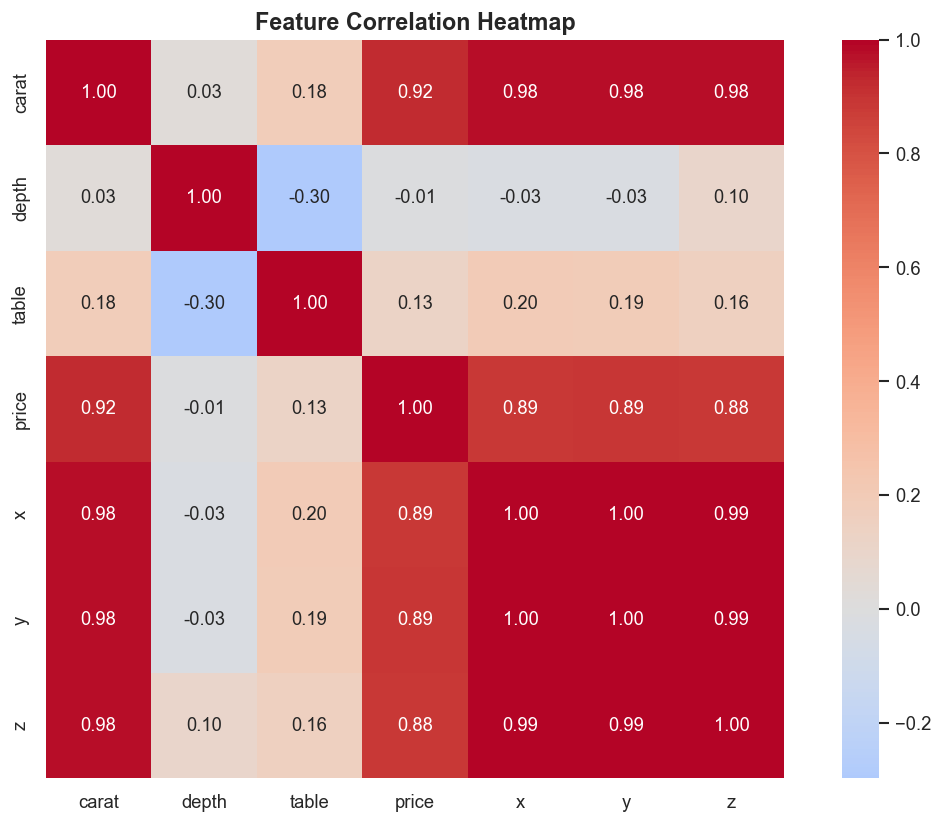

In [9]:
# ============================================================
# EDA — CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=np.number)
correlation = numeric_cols.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA Summary & Hypothesis Testing Results

| Hypothesis | Result | Evidence |
|------------|--------|----------|
| H1: Carat is the strongest predictor of price | ✅ Accepted | Correlation = 0.92 (highest of all features) |
| H2: Better cut = higher price | ❌ Rejected | Ideal cut avg ($3,462) < Premium avg ($4,578) |
| H3: Better color = higher price | ❌ Rejected | D color avg ($3,172) < J color avg ($5,326) |
| H4: Better clarity = higher price | ❌ Rejected | IF clarity avg ($2,870) < SI2 avg ($5,053) |

### Key Insight
> **Carat dominates price above everything else.**  
> Better quality grades (cut/color/clarity) do NOT guarantee higher price because high-quality diamonds tend to come in smaller sizes — this is called the **"carat size confounding effect"**.

---
## Step 7 — Identifying Root Causes

In [10]:
# ============================================================
# ROOT CAUSE ANALYSIS
# ============================================================

cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

print("--- Avg Carat by Cut ---")
print(df.groupby('cut')['carat'].mean().loc[cut_order].round(3))

print("\n--- Avg Carat by Color ---")
print(df.groupby('color')['carat'].mean().loc[color_order].round(3))

print("\n--- Avg Carat by Clarity ---")
print(df.groupby('clarity')['carat'].mean().loc[clarity_order].round(3))

--- Avg Carat by Cut ---
cut
Fair         1.044
Good         0.847
Very Good    0.806
Premium      0.891
Ideal        0.703
Name: carat, dtype: float64

--- Avg Carat by Color ---
color
D    0.658
E    0.658
F    0.737
G    0.771
H    0.910
I    1.025
J    1.163
Name: carat, dtype: float64

--- Avg Carat by Clarity ---
clarity
IF      0.506
VVS1    0.504
VVS2    0.597
VS1     0.727
VS2     0.764
SI1     0.850
SI2     1.076
I1      1.284
Name: carat, dtype: float64


### Root Cause Analysis Results

**Why do better quality diamonds have LOWER average price?**

| Category | Best Grade (Avg Carat) | Worst Grade (Avg Carat) |
|----------|----------------------|------------------------|
| Cut | Ideal = 0.703 ct | Fair = 1.044 ct |
| Color | D = 0.658 ct | J = 1.163 ct |
| Clarity | IF = 0.506 ct | I1 = 1.284 ct |

### Root Cause: Carat Size Confounding Effect
> - Best quality diamonds (Ideal cut, D color, IF clarity) come in **smaller carat sizes**
> - Worst quality diamonds (Fair cut, J color, I1 clarity) come in **larger carat sizes**
> - Since carat drives price (correlation = 0.92), larger low-quality diamonds end up **more expensive** on average
> - This does NOT mean low quality is better — it means **carat weight masks quality premiums**

---
## Step 8 — Insights & Recommendations

### Insights & Recommendations

| # | Insight | Recommendation | Expected Impact |
|---|---------|----------------|-----------------|
| 1 | Carat is the #1 price driver (correlation = 0.92) | Buyers should prioritize carat weight when budgeting | Better value for money |
| 2 | Ideal cut diamonds are smaller on average (0.703 ct) | Retailers should market Ideal cut as premium quality, not premium price | Increase Ideal cut sales |
| 3 | D color diamonds are underpriced relative to quality | Buyers looking for best color should target D-F grades for best value | Save 10-20% vs J color per carat |
| 4 | IF clarity diamonds are smallest on average (0.506 ct) | For large diamonds, VS1-VS2 clarity offers best quality/price balance | Reduce overpaying on clarity |
| 5 | 6.54% of diamonds are anomalously priced | Retailers should review anomalous pricing to avoid revenue loss | Correct mispricing across 3,519 diamonds |

---
## Step 9 — Dashboard / Visualization

The interactive dashboard is built with **Streamlit** and covers all analysis results.

**File:** `dashboard/app.py`  
**Run command:**
```bash
streamlit run dashboard/app.py
```

**Dashboard Sections:**
| Section | Content |
|---------|---------|
|  Overview | Dataset summary and KPIs |
|  EDA | Price distributions and category analysis |
|  Price Predictor | Predict diamond price using Regression |
|  Market Segments | Explore diamond clusters |

---
## Step 10 — Final Deliverables

| Deliverable | File | Status |
|-------------|------|--------|
| Cleaned Dataset | `data/diamonds.csv` | ✅ |
| Analysis Notebook | `notebooks/diamonds_dav_analysis.ipynb` | ✅ |
| Dashboard | `dashboard/app.py` | ✅ |

### Project Summary
| Question | Answer |
|----------|--------|
| What is the problem? | Diamond pricing lacks transparency for buyers and retailers |
| What does the data show? | Carat is the #1 price driver (correlation = 0.92) |
| Why is it happening? | Carat size confounding effect masks quality premiums |
| What should be done? | Use carat-adjusted pricing benchmarks and review anomalous diamonds |

---
## Bonus — Machine Learning Models

### Models Included
1. **Clustering (K-Means)** — Segment diamonds into natural market groups
2. **Regression (Polynomial + Ridge)** — Predict diamond price from features

In [11]:
# ============================================================
# BONUS — CLUSTERING (K-Means)
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare features
features = ['carat', 'price']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster labels
cluster_names = {0: 'Budget', 1: 'Mid-Range', 2: 'Upper Mid-Range', 3: 'Luxury'}
df['cluster_label'] = df['cluster'].map(cluster_names)

print("--- Cluster Summary ---")
print(df.groupby('cluster_label')[['carat', 'price']].mean().round(2))

--- Cluster Summary ---
                 carat     price
cluster_label                   
Budget            0.40   1054.96
Luxury            0.89   3696.55
Mid-Range         1.27   7803.01
Upper Mid-Range   1.87  14387.20


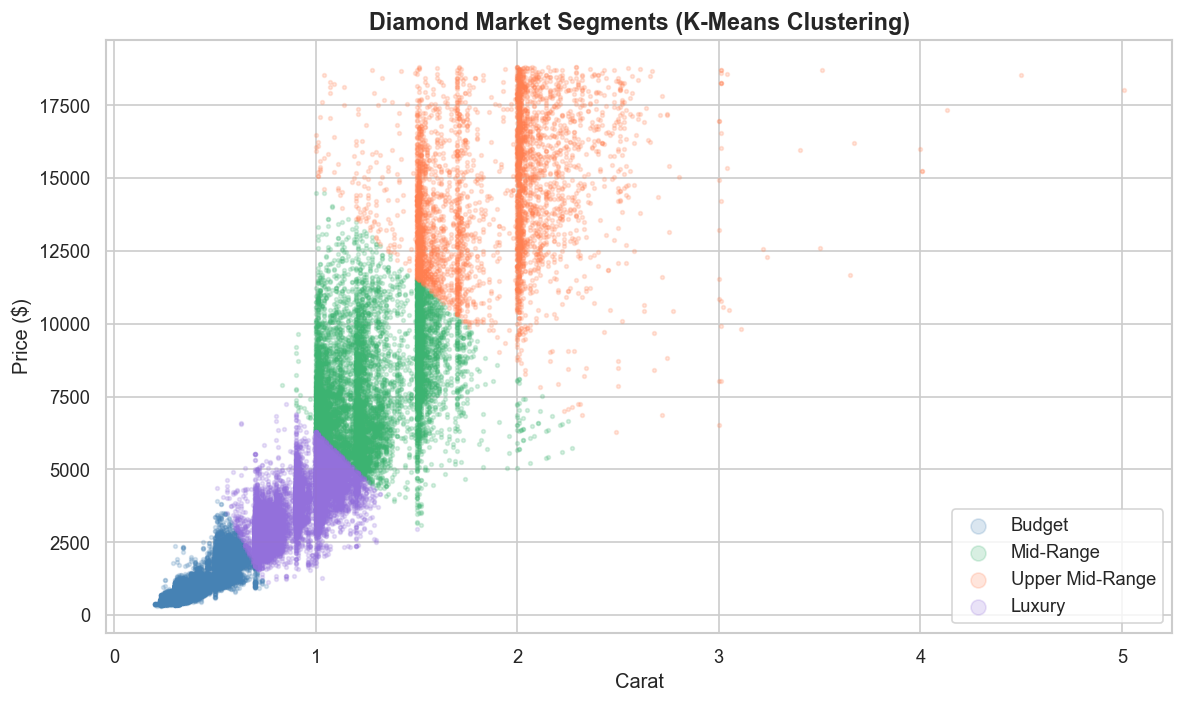

In [12]:
# ============================================================
# CLUSTERING — VISUALIZATION
# ============================================================

colors = {'Budget': 'steelblue', 'Mid-Range': 'mediumseagreen', 
          'Upper Mid-Range': 'coral', 'Luxury': 'mediumpurple'}

plt.figure(figsize=(10, 6))
for label, color in colors.items():
    mask = df['cluster_label'] == label
    plt.scatter(df[mask]['carat'], df[mask]['price'],
                alpha=0.2, s=5, color=color, label=label)

plt.title('Diamond Market Segments (K-Means Clustering)', fontsize=14, fontweight='bold')
plt.xlabel('Carat')
plt.ylabel('Price ($)')
plt.legend(markerscale=4)
plt.tight_layout()
plt.savefig('../data/clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================
# BONUS — REGRESSION (Polynomial + Ridge)
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Prepare features
features = ['carat', 'depth', 'table', 'x', 'y', 'z',
            'cut_encoded', 'color_encoded', 'clarity_encoded']

# Encode categorical
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df['cut_encoded']     = df['cut'].map({v: i+1 for i, v in enumerate(cut_order)})
df['color_encoded']   = df['color'].map({v: i+1 for i, v in enumerate(color_order)})
df['clarity_encoded'] = df['clarity'].map({v: i+1 for i, v in enumerate(clarity_order)})

X = df[features].values
y = np.log(df['price'].values)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {np.sqrt(mse):.4f}")
print(f"\nBusiness Goal (R² > 0.90): {' MET' if r2 >= 0.90 else '❌ NOT MET'}")

R² Score : 0.9858
RMSE     : 0.1203

Business Goal (R² > 0.90):  MET


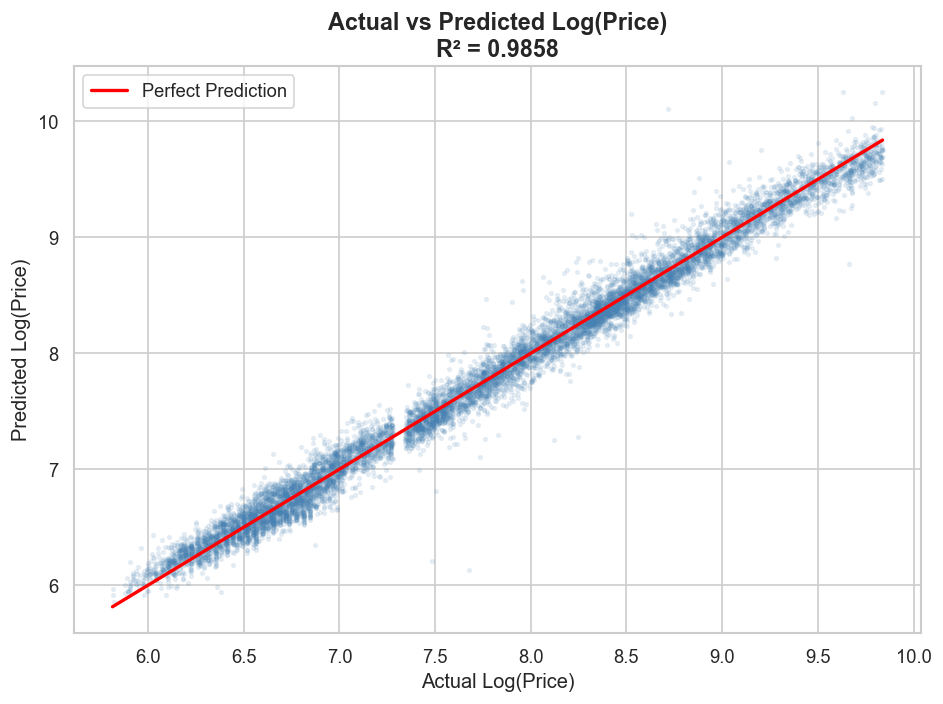

In [16]:
# ============================================================
# REGRESSION — VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.1, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         color='red', linewidth=2, label='Perfect Prediction')

plt.title(f'Actual vs Predicted Log(Price)\nR² = {r2:.4f}', fontsize=14, fontweight='bold')
plt.xlabel('Actual Log(Price)')
plt.ylabel('Predicted Log(Price)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/regression_results.png', dpi=150, bbox_inches='tight')
plt.show()